# Exercise 2 - Split in the Roman Triumvirate

<img src="ex2.png">

## Imports

In [ ]:
import pickle
import networkx as nx
import random
import numpy as np
import os
import pymc as pm
import matplotlib.pyplot as plt
import arviz as az
import pandas as pd
import pytensor.tensor as pt

## Set Seed 

In [2]:
SEED = 23
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
rng = np.random.default_rng(SEED)

## Load data

In [3]:
G = pickle.load(open('ex_2_graph.pickle', 'rb'))
known_assignments_df = pd.read_csv('ex_2_assignments.csv')

# Basic information about the graph
print("Graph object type:", type(G))
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Graph is directed:", G.is_directed()) # Important that is not directed

# Check if there are 3 factions present
factions = sorted(set(attrs["faction"] for _, attrs in G.nodes(data=True)))
print("\nFactions present in the network:", factions)
print()

# Check nodes + edges with attributes
for node, attributes in list(G.nodes(data=True))[:3]:
    print(f"Node {node}: {attributes}")
print()
for u, v, attributes in list(G.edges(data=True))[:3]:
    print(f"Edge ({u}, {v}): {attributes}")

Graph object type: <class 'networkx.classes.graph.Graph'>
Number of nodes: 100
Number of edges: 1084
Graph is directed: False

Factions present in the network: ['Caesar', 'Crassus', 'Pompey']

Node 0: {'faction': 'Caesar'}
Node 1: {'faction': 'Caesar'}
Node 2: {'faction': 'Caesar'}

Edge (0, 1): {'meetings': 30}
Edge (0, 2): {'meetings': 28}
Edge (0, 6): {'meetings': 27}


## Create label array for model
Logic:
* **0 (Caesar):** Nodes originally Caesar OR Crassus nodes labeled 'Caesar' in the  assignments CSV.
* **1 (Pompey):** Nodes originally Pompey OR Crassus nodes labeled 'Pompey' in the assignments CSV.
* **2 (Undecided):** Crassus nodes that are NOT in the CSV. **(These are our prediction targets)**.

In [4]:
label_map = {'Caesar': 0, 'Pompey': 1}

nodes = list(G.nodes())
N = len(nodes)
node_to_idx = {n: i for i, n in enumerate(nodes)}

#initialize array with 2 (Default to Undecided)
faction_code = np.full(N, 2, dtype=int)

original_crassus_indices = [] 

for i, node in enumerate(nodes):
    f_orig = G.nodes[node]['faction']
    
    # Case A: Originally Caesar/Pompey
    if f_orig == 'Caesar':
        faction_code[i] = 0
    elif f_orig == 'Pompey':
        faction_code[i] = 1
        
    # Case B: Originally Crassus
    elif f_orig == 'Crassus':
        original_crassus_indices.append(i)
        if node in known_assignments_df['node_id'].values:
            new_label = known_assignments_df.loc[known_assignments_df['node_id'] == node, 'new_faction'].values[0]
            faction_code[i] = label_map[new_label]

n_caesar = (faction_code == 0).sum()
n_pompey = (faction_code == 1).sum()
n_undecided = (faction_code == 2).sum()

print("Political Landscape After the Death of Crassus:")
print(f"Caesar (0):    {n_caesar}")
print(f"Pompey (1):    {n_pompey}")
print(f"Undecided (2): {n_undecided}")
print()
print(f"Originally Crassus members: {len(original_crassus_indices)}")
print(f" - Assigned to Caesar: {(faction_code[original_crassus_indices] == 0).sum()}")
print(f" - Assigned to Pompey: {(faction_code[original_crassus_indices] == 1).sum()}")
print(f" - Still Undecided: {(faction_code[original_crassus_indices] == 2).sum()}")

Political Landscape After the Death of Crassus:
Caesar (0):    40
Pompey (1):    40
Undecided (2): 20

Originally Crassus members: 40
 - Assigned to Caesar: 10
 - Assigned to Pompey: 10
 - Still Undecided: 20


## Data Visualization (Structure)

Red   -> Caesar (Core + Coverted)
Blue  -> Pompey (Core + Converted)
Yellow -> Undecided (Target) from Crassus


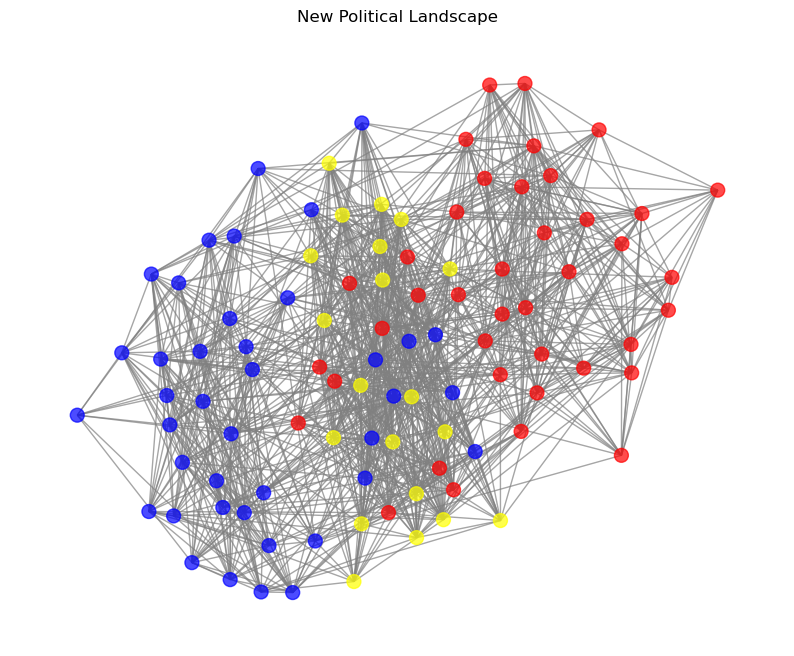

In [5]:
pos = nx.spring_layout(G, seed=SEED + 1)
colors = []
for code in faction_code:
    if code == 0:
        colors.append('red')       
    elif code == 1:
        colors.append('blue')      
    else:
        colors.append('yellow') 

print("Red   -> Caesar (Core + Coverted)")
print("Blue  -> Pompey (Core + Converted)")
print("Yellow -> Undecided (Target) from Crassus")

plt.figure(figsize=(10, 8))
nx.draw_networkx(G, pos=pos, with_labels=False, node_color=colors, node_size=100, edge_color='gray', alpha=0.7)
plt.title("New Political Landscape")
plt.axis('off')
plt.show()

## Data Visualization (Edges width depends on the volume of meetings)

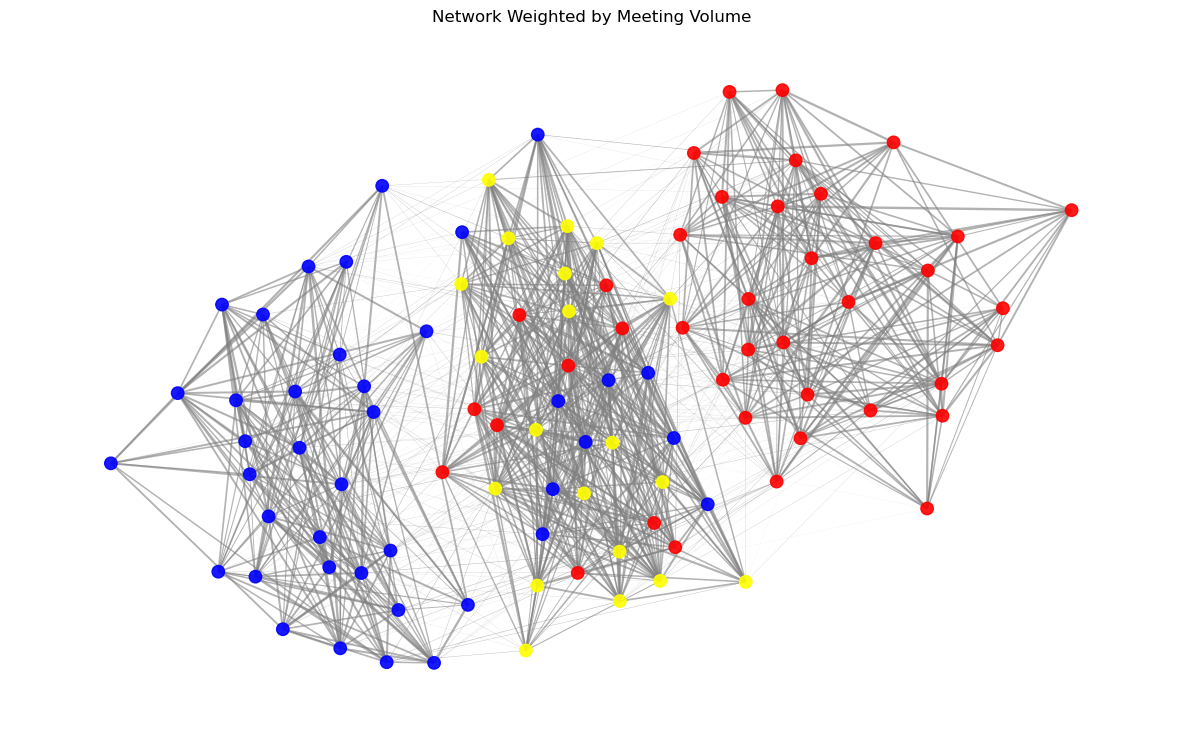

Max meetings on an edge: 45


In [6]:
# Extract edge meetings
edge_meetings = [G[u][v]["meetings"] for u, v in G.edges()]

# Normalize edge widths for plotting
max_weight = max(edge_meetings)
edge_widths = [(w / max_weight) * 2 for w in edge_meetings]
plt.figure(figsize=(15, 9))

# Draw nodes
nx.draw_networkx_nodes(G,pos=pos,node_size=80,node_color=colors,alpha=0.9)
# Draw weighted edges
nx.draw_networkx_edges(G,pos,edge_color="gray",width=edge_widths,alpha=0.6)

plt.title("Network Weighted by Meeting Volume")
plt.axis("off")
plt.show()
print("Max meetings on an edge:", max_weight)

### Interpretation (after seeing the graph)
1. The "Crassus" faction is visibly dissapearring. the 3-faction system slowly becomes Ceasar vs Pompey
2. The undecided politicians (remaining of Crassus) appear "scrambled" but this is why we will use a latent space 

## Data Prep 

In [7]:
# Create indexed node list and count
nodes = list(G.nodes())
N = len(nodes)
print("N =", N)

# Create faction array
faction = faction_code
print("Faction counts:", np.bincount(faction))
print("0=Caesar, 1=Pompey, 2=Undecided")

# Extract data into arrays for modeling
src = []
dst = []
y = []

for u, v, data in G.edges(data=True):
    src.append(u)
    dst.append(v)
    y.append(data["meetings"])

src = np.array(src, dtype=int)
dst = np.array(dst, dtype=int)
y = np.array(y, dtype=float)

print("\nobserved edges=", len(y))
print("Meetings summary:")
print(pd.Series(y).describe())

# Sanity check: within vs cross-faction edges
same_faction = (faction[src] == faction[dst])

print("Within-faction edges:", int(same_faction.sum()))
print("Cross-faction edges:", int((~same_faction).sum()))

print("\nAverage messages per edge:")
print("within-faction:", y[same_faction].mean() if same_faction.any() else None)
print("cross-faction:", y[~same_faction].mean() if (~same_faction).any() else None)

N = 100
Faction counts: [40 40 20]
0=Caesar, 1=Pompey, 2=Undecided

observed edges= 1084
Meetings summary:
count    1084.000000
mean       20.497232
std        11.243424
min         1.000000
25%        11.000000
50%        24.000000
75%        29.000000
max        45.000000
dtype: float64
Within-faction edges: 614
Cross-faction edges: 470

Average messages per edge:
within-faction: 24.019543973941367
cross-faction: 15.895744680851063


### Modelling Assumptions

The network model is modeled as an **UNDIRECTED GRAPH** --> meetings represent mutual interaction between 2 members.

Result ==> each edge m_ij will be treated simetrically in the latent space model 

Challenge: 
- Unlike Exercise 1, we now have a triangular problem. 
  - Crassus members have historical ties to both Caesar and Pompey. We need to see if a standard geometric model can "break" these ties correctly or if it gets confused.


## Build dyad data (including zero-meetings pairs)

1. We include all unordered node pairs (i, j).
2. If an edge is present, we use its observed meetings count. Otherwise we record 0 meetings.

In [8]:
# Build a lookup table for meeting counts on observed edges
meeting_lookup = {}

for u, v, data in G.edges(data=True):
    # Map node names to indices using the dict we created in Data Prep
    idx_u = node_to_idx[u]
    idx_v = node_to_idx[v]
    
    i, j = (idx_u, idx_v) if idx_u < idx_v else (idx_v, idx_u)  # enforce i < j
    meeting_lookup[(i, j)] = data["meetings"]

# Build full dyad arrays (all i<j)
dyad_i = []
dyad_j = []
dyad_y = []
dyad_same = []

for i in range(N):
    for j in range(i + 1, N):
        dyad_i.append(i)
        dyad_j.append(j)
        
        # Get meetings (0 if no edge)
        dyad_y.append(meeting_lookup.get((i, j), 0))
        
        # Check faction equality (0=0, 1=1, 2=2)
        dyad_same.append(int(faction[i] == faction[j]))

dyad_i = np.array(dyad_i, dtype=int)
dyad_j = np.array(dyad_j, dtype=int)
dyad_y = np.array(dyad_y, dtype=float)
dyad_same = np.array(dyad_same, dtype=int)

print("Total dyads (all pairs i<j):", len(dyad_y))
print("Nonzero dyads (edges):", int((dyad_y > 0).sum()))
print("Zero dyads (no interaction):", int((dyad_y == 0).sum()))

print("\nAverage meetings per dyad:")
print("overall:", dyad_y.mean())
print("same faction:", dyad_y[dyad_same == 1].mean())
print("different factions:", dyad_y[dyad_same == 0].mean())

Total dyads (all pairs i<j): 4950
Nonzero dyads (edges): 1084
Zero dyads (no interaction): 3866

Average meetings per dyad:
overall: 4.488686868686869
same faction: 8.427428571428571
different factions: 2.3346875


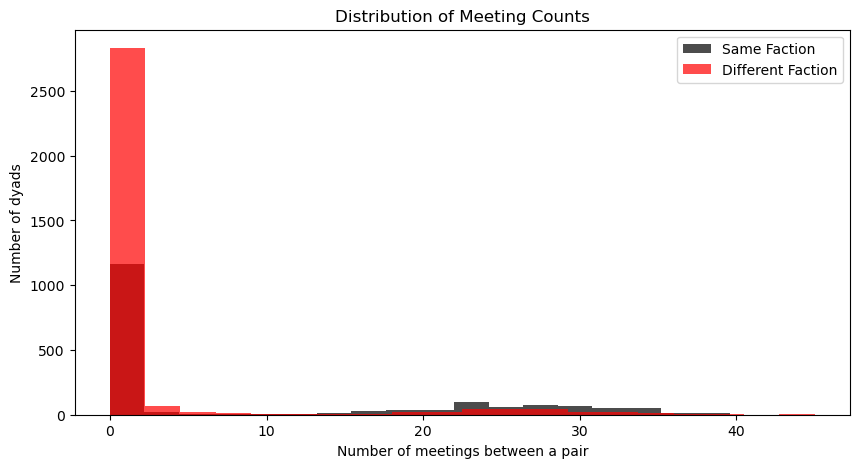

In [9]:
y_same = dyad_y[(dyad_same == 1)]
y_diff = dyad_y[(dyad_same == 0)]

plt.figure(figsize=(10, 5))

plt.hist(y_same, bins=20, alpha=0.7, label="Same Faction", color='black')
plt.hist(y_diff, bins=20, alpha=0.7, label="Different Faction", color='red')

plt.xlabel("Number of meetings between a pair")
plt.ylabel("Number of dyads")
plt.title("Distribution of Meeting Counts")
plt.legend()
plt.show()

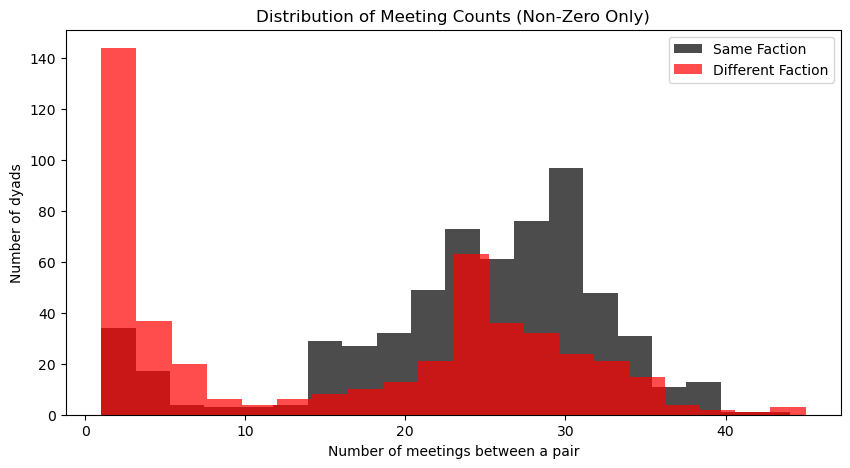

In [10]:
y_same = dyad_y[(dyad_same == 1) & (dyad_y > 0)]
y_diff = dyad_y[(dyad_same == 0) & (dyad_y > 0)]

plt.figure(figsize=(10, 5))

plt.hist(y_same, bins=20, alpha=0.7, label="Same Faction", color='black')
plt.hist(y_diff, bins=20, alpha=0.7, label="Different Faction", color='red')

plt.xlabel("Number of meetings between a pair")
plt.ylabel("Number of dyads")
plt.title("Distribution of Meeting Counts (Non-Zero Only)")
plt.legend()
plt.show()

## 1. Baseline model (LS-ZIP)

- First i want to try to use the model from Exercise 1.

I will use a simplified **Latent Space Zero-Inflated Poisson (LS-ZIP)** model.

* **Priors:** $Z \sim \text{Normal}(0, 1)$ (we tell the model nothing about factions).
* **Covariates:** None. We rely purely on geometric distance.
  
**Goal:** I hope the geometry naturally separates the groups.

In [14]:
coords = {
    "node": np.arange(N),
    "dim": np.arange(2),
    "dyad": np.arange(len(dyad_y)),
}

with pm.Model(coords=coords) as baseline_model:

    # Data
    i_idx = pm.Data("i_idx", dyad_i, dims="dyad")
    j_idx = pm.Data("j_idx", dyad_j, dims="dyad")
    y_obs = pm.Data("y_obs", dyad_y, dims="dyad")

    # 1. Zero-Inflation Process (Psi)
    # controls the prob of being a 0
    # Priors
    psi = pm.math.invlogit(pm.Normal("gamma0", mu=0.0, sigma=1.5))

    # 2. Count Process (Lambda)
    # number of messages when not a structural zero
    # Priors
    z = pm.Normal("z", mu=0.0, sigma=1.0, dims=("node", "dim"))
    alpha = pm.Normal("alpha", mu=0.0, sigma=2.0)

    # Calculate Euclidean distances
    zi = z[i_idx]
    zj = z[j_idx]
    distance = pt.sqrt(pt.sum((zi - zj)**2, axis=1) + 1e-5)

    # Poisson rate driven by distance (same as Baseline)
    log_lambda = alpha - distance
    lbd = pm.math.exp(log_lambda)

    # Likelihood
    y = pm.ZeroInflatedPoisson(
        "y", 
        psi=psi, 
        mu=lbd, 
        observed=y_obs, 
        dims="dyad"
    )

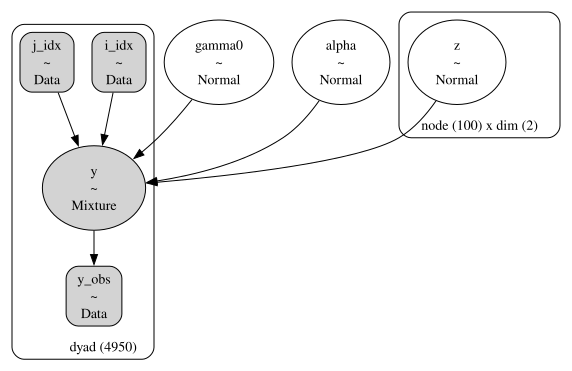

In [15]:
pm.model_to_graphviz(baseline_model)

In [16]:
with baseline_model:
    idata_baseline = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        random_seed=SEED
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [gamma0, z, alpha]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 399 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


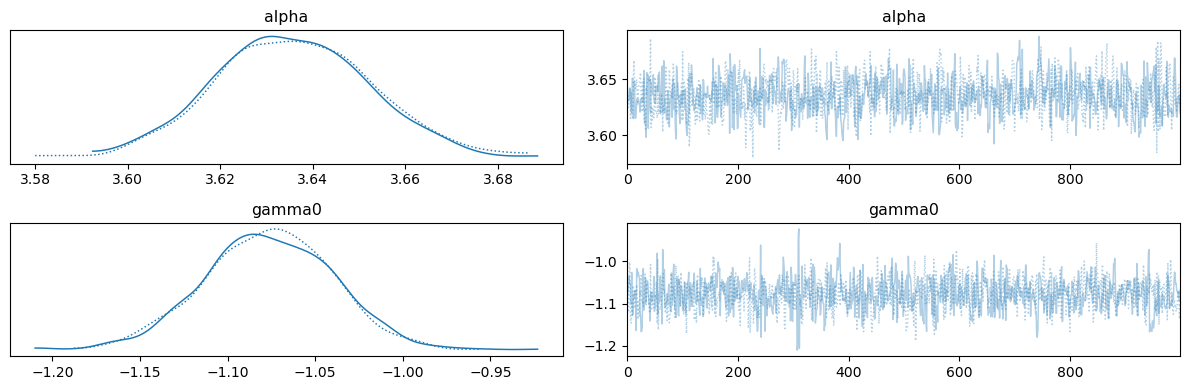

In [17]:
az.plot_trace(idata_baseline, var_names=["alpha", "gamma0"])
plt.tight_layout()
plt.show()

In [18]:
summary_baseline = az.summary(idata_baseline, var_names=["gamma0","alpha"])
print(summary_baseline)

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
gamma0 -1.077  0.037  -1.142   -1.006      0.001    0.001    1094.0     876.0   
alpha   3.636  0.016   3.604    3.666      0.001    0.000     982.0     840.0   

        r_hat  
gamma0    1.0  
alpha     1.0  


Sampling: [y]


Output()

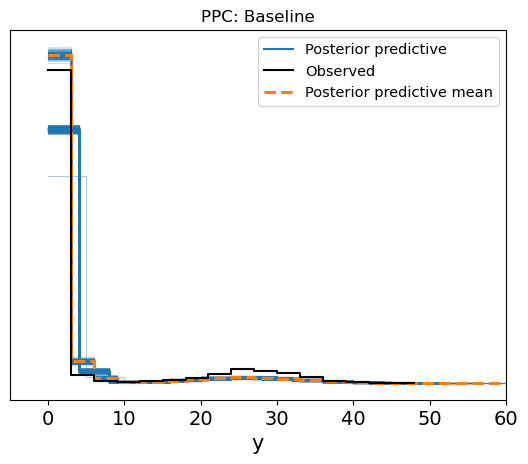

In [19]:
with baseline_model:
    ppc_baseline = pm.sample_posterior_predictive(
        idata_baseline,
        var_names=["y"],
        random_seed=SEED,
        extend_inferencedata=True
    )

az.plot_ppc(ppc_baseline, num_pp_samples=500)
plt.xlim(-5, 60)
plt.title("PPC: Baseline")
plt.show()

### Model Validation 
- Calculation of the accuracy on the 20 known Crassus members in the CSV

**Method:** Calculate the Centroid of the Core Caesar group and Core Pompey group. Check which centroid the members are closer to

In [21]:
z_post = idata_baseline.posterior["z"].mean(dim=["chain", "draw"]).values

# Calculate Centroids based on Core Members
idx_c = np.where(faction_code == 0)[0]
idx_p = np.where(faction_code == 1)[0]
centroid_c = z_post[idx_c].mean(axis=0)
centroid_p = z_post[idx_p].mean(axis=0)

correct = 0
total = 0
for _, row in known_assignments_df.iterrows():
    idx = node_to_idx[row['node_id']]
    pos = z_post[idx]

    # Geometric Prediction
    d_c = np.linalg.norm(pos - centroid_c)
    d_p = np.linalg.norm(pos - centroid_p)
    pred = "Caesar" if d_c < d_p else "Pompey"
    
    if pred == row['new_faction']: 
        correct += 1
    else:
        print(f"[MISMATCH] Node {row['node_id']}: Closer to {pred}, but switched to {row['new_faction']}")
    total += 1

print(f"Accuracy: {correct}/{total} ({correct/total:.1%})")

[MISMATCH] Node 94: Closer to Caesar, but switched to Pompey
[MISMATCH] Node 70: Closer to Caesar, but switched to Pompey
[MISMATCH] Node 69: Closer to Caesar, but switched to Pompey
[MISMATCH] Node 74: Closer to Caesar, but switched to Pompey
[MISMATCH] Node 60: Closer to Caesar, but switched to Pompey
[MISMATCH] Node 86: Closer to Caesar, but switched to Pompey
[MISMATCH] Node 91: Closer to Caesar, but switched to Pompey
[MISMATCH] Node 76: Closer to Caesar, but switched to Pompey
[MISMATCH] Node 95: Closer to Caesar, but switched to Pompey
[MISMATCH] Node 87: Closer to Caesar, but switched to Pompey
Accuracy: 10/20 (50.0%)


### Latent Space Plot -> Baseline

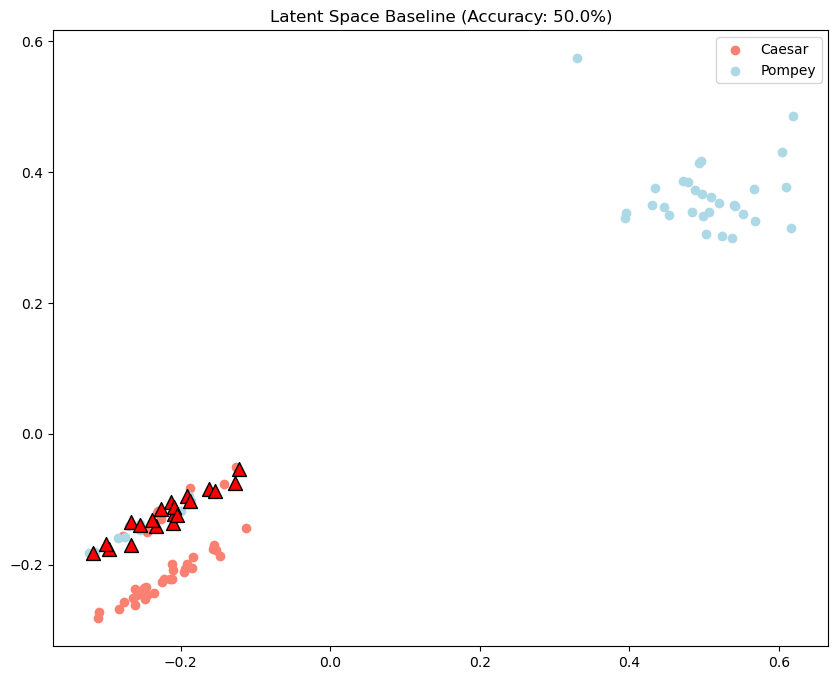

In [ ]:
unknown_nodes = [n for n in nodes if G.nodes[n]['faction'] in ['Crassus'] and n not in known_assignments_df['node_id'].values]
results = []
for n in unknown_nodes:
    idx = node_to_idx[n]
    pos = z_post[idx]
    d_c = np.linalg.norm(pos - centroid_c)
    d_p = np.linalg.norm(pos - centroid_p)
    res = {'node': n, 'choice': 'Caesar' if d_c < d_p else 'Pompey'}
    results.append(res)

df_res = pd.DataFrame(results)

plt.figure(figsize=(10, 8))

# Plot Knowns
plt.scatter(z_post[idx_c,0], z_post[idx_c,1], c='salmon', label='Caesar')
plt.scatter(z_post[idx_p,0], z_post[idx_p,1], c='lightblue', label='Pompey')
# Plot Predictions
for _, r in df_res.iterrows():
    col = 'red' if r['choice']=='Caesar' else 'blue'
    idx = node_to_idx[r['node']]
    plt.scatter(z_post[idx,0], z_post[idx,1], c=col, marker='^', s=100, edgecolors='k')
plt.legend()
plt.title(f"Latent Space Baseline (Accuracy: {correct/total:.1%})")
plt.show()

## 1. Baseline model (LS-ZIP) - Evaluation
- The model failed significantly, achieving an accuracy of 50%, same as random guessing. It classified all remaining members of Crassus to a single faction (Caesar).

- The space failed to separate the Caesar and Pompey clusters in opposite poles and position Crassus between them.

- I think without external information (priors) the model has no way to distinguish between Pompey and Caesar.

- The model collapsed as the Crassus members acted like a "bridge" pulling Caesar and Pompey close to each other and Crassus was too close to PPompey


## 2.LS-ZIP Enhanced

To fix the problem from the previous trial, I plan to use the CSV provided in the assignment to create a good framework for the model

**Idea** Instead of letting the model guess the position of every node from scratch (as we saw it led to chaos), we provide it with a skeleton. We pin the known factions to opposite corners of the space and let the "social gravity" handle the rest.

**Mechanic** We customize the prior for every single node based on what we know.

We need to define (Location $\mu$) and (Uncertainty $\sigma$).

**Definition of $\mu$:**
We define an axis running diagonally across the map
* **Ceasar Triumvirate + Converted Crassus** --> at **$(-2, -2)$** (Bottom-Left)
* **Pompey Triumvirate + Converted Crassus** --> at **$(+2, +2)$** (Top-Right).
* **Undecided Nodes:** --> at **$(0, 0)$** (The neutral middle).

**Definition of $\sigma$:**
This controls how much freedom a node has to move away from the location.
* **Known Nodes** (Data + CSV) --> **$\sigma = 0.5$**
* **Undecided Nodes** (What we need to predict) --> **$\sigma = 3.0$**


In [11]:
prior_mu = np.zeros((N, 2))
prior_sigma = np.ones((N, 2)) * 3.0

fixed_nodes = 0
for i in range(N):
    f = faction_code[i]
    if f == 0:   # Caesar
        prior_mu[i] = [-2.0, -2.0]
        prior_sigma[i] = 0.5    # Tight leash
        fixed_nodes += 1
    elif f == 1: # Pompey
        prior_mu[i] = [2.0, 2.0]
        prior_sigma[i] = 0.5    # Tight leash
        fixed_nodes += 1

print(f"Fixed nodes in prior: {fixed_nodes} / {N}")
print(f"Free to move: {N - fixed_nodes} / {N}")

Fixed nodes in prior: 80 / 100
Free to move: 20 / 100


In [12]:
coords = {
    "node": np.arange(N),
    "dim": np.arange(2),
    "dyad": np.arange(len(dyad_y)),
}

with pm.Model(coords=coords) as lszip_enhanced:

    # Data
    i_idx = pm.Data("i_idx", dyad_i, dims="dyad")
    j_idx = pm.Data("j_idx", dyad_j, dims="dyad")
    y_obs = pm.Data("y_obs", dyad_y, dims="dyad")

    # 1. Zero-Inflation Process (Psi)
    # controls the prob of being a 0
    # Priors
    gamma0 = pm.Normal("gamma0", mu=0.0, sigma=1.5)
    psi = pm.math.invlogit(gamma0)

    # 2. Count Process (Lambda)
    # number of messages when not a structural zero
    # Priors
    z = pm.Normal("z", mu=prior_mu, sigma=prior_sigma, dims=("node", "dim")) # Enhanced Prior
    alpha = pm.Normal("alpha", mu=0.0, sigma=2.0)

    # Calculate Euclidean distances
    zi = z[i_idx]
    zj = z[j_idx]
    distance = pt.sqrt(pt.sum((zi - zj)**2, axis=1) + 1e-5)

    # Poisson rate driven by distance (same as Baseline)
    log_lambda = alpha - distance
    lbd = pm.math.exp(log_lambda)

    # Likelihood
    y = pm.ZeroInflatedPoisson(
        "y", 
        psi=psi, 
        mu=lbd, 
        observed=y_obs, 
        dims="dyad"
    )

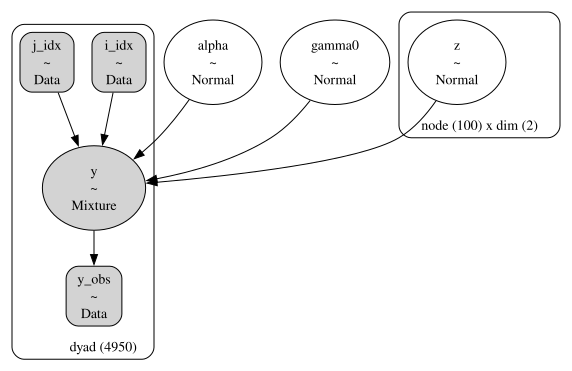

In [13]:
pm.model_to_graphviz(lszip_enhanced)

In [14]:
with lszip_enhanced:
    idata_lszip_enhanced = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        random_seed=SEED
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [gamma0, z, alpha]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 106 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


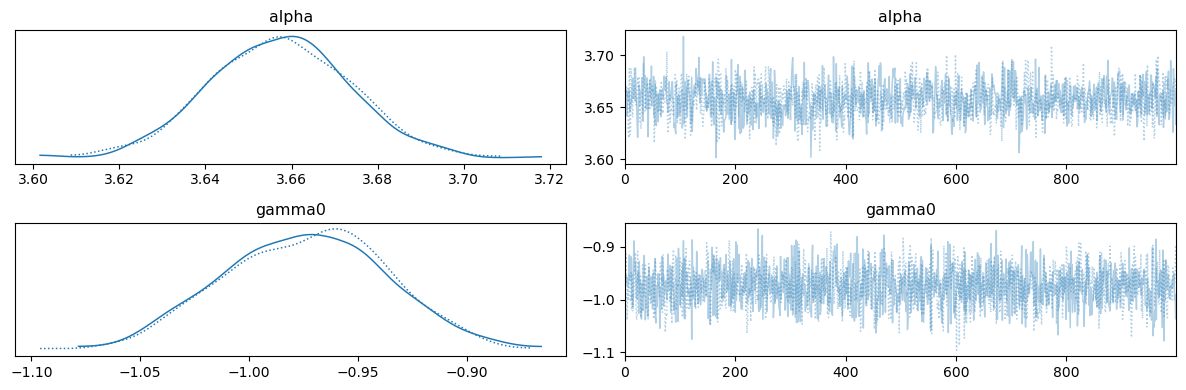

In [15]:
az.plot_trace(idata_lszip_enhanced, var_names=["alpha", "gamma0"])
plt.tight_layout()
plt.show()

In [17]:
summary_lszip_enhanced = az.summary(idata_lszip_enhanced, var_names=["gamma0","alpha"])
print(summary_lszip_enhanced)

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
gamma0 -0.974  0.037  -1.043   -0.908      0.001    0.001    2007.0    1440.0   
alpha   3.657  0.016   3.629    3.690      0.000    0.000    1267.0    1323.0   

        r_hat  
gamma0    1.0  
alpha     1.0  


Sampling: [y]


Output()

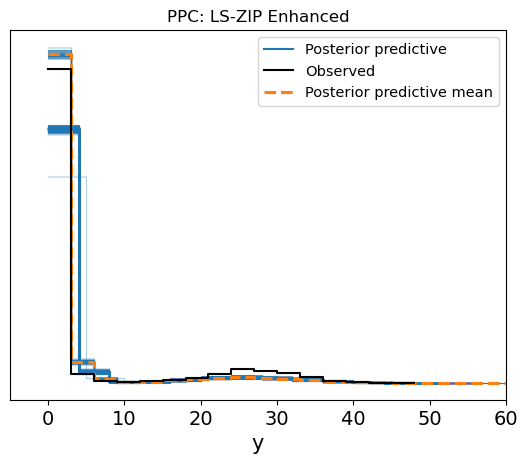

In [18]:
with lszip_enhanced:
    ppc_lszip_enhanced = pm.sample_posterior_predictive(
        idata_lszip_enhanced,
        var_names=["y"],
        random_seed=SEED,
        extend_inferencedata=True
    )

az.plot_ppc(ppc_lszip_enhanced, num_pp_samples=500)
plt.xlim(-5, 60)
plt.title("PPC: LS-ZIP Enhanced")
plt.show()

### Model Validation 

In [19]:
z_post = idata_lszip_enhanced.posterior["z"].mean(dim=["chain", "draw"]).values

# Calculate Centroids based on Core Members
idx_c = np.where(faction_code == 0)[0]
idx_p = np.where(faction_code == 1)[0]
centroid_c = z_post[idx_c].mean(axis=0)
centroid_p = z_post[idx_p].mean(axis=0)

correct = 0
total = 0
for _, row in known_assignments_df.iterrows():
    idx = node_to_idx[row['node_id']]
    pos = z_post[idx]

    # Geometric Prediction
    d_c = np.linalg.norm(pos - centroid_c)
    d_p = np.linalg.norm(pos - centroid_p)
    pred = "Caesar" if d_c < d_p else "Pompey"
    
    if pred == row['new_faction']: 
        correct += 1
    else:
        print(f"[MISMATCH] Node {row['node_id']}: Closer to {pred}, but switched to {row['new_faction']}")
    total += 1

print(f"Accuracy: {correct}/{total} ({correct/total:.1%})")

[MISMATCH] Node 84: Closer to Pompey, but switched to Caesar
[MISMATCH] Node 99: Closer to Pompey, but switched to Caesar
Accuracy: 18/20 (90.0%)


### Latent Space Plot -> LS-ZIP Enhanced

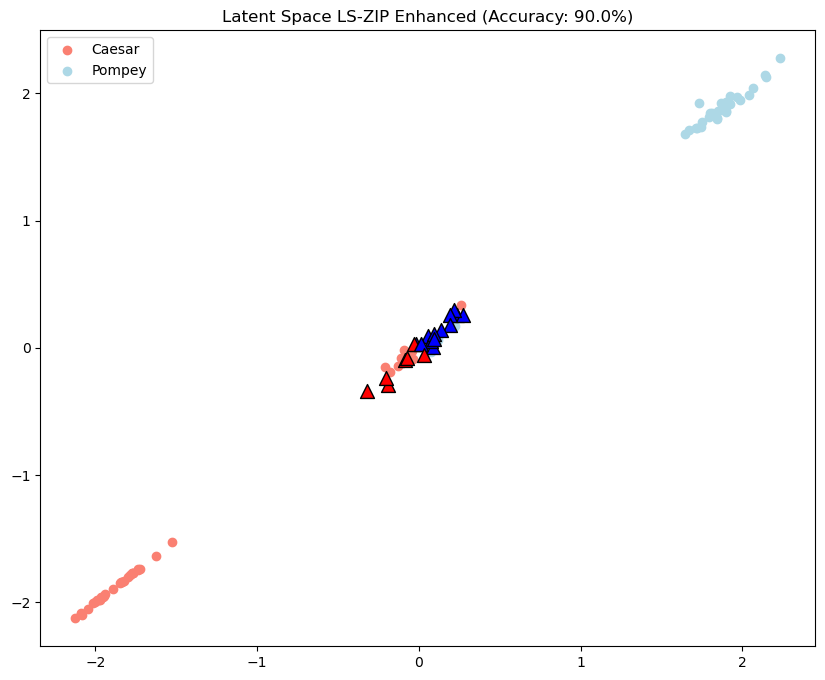

In [ ]:
unknown_nodes = [n for n in nodes if G.nodes[n]['faction'] in ['Crassus'] and n not in known_assignments_df['node_id'].values]
results = []
for n in unknown_nodes:
    idx = node_to_idx[n]
    pos = z_post[idx]
    d_c = np.linalg.norm(pos - centroid_c)
    d_p = np.linalg.norm(pos - centroid_p)
    res = {'node': n, 'choice': 'Caesar' if d_c < d_p else 'Pompey', 'unc': abs(d_c - d_p)}
    results.append(res)

df_res = pd.DataFrame(results)

plt.figure(figsize=(10, 8))

# Plot Knowns
plt.scatter(z_post[idx_c,0], z_post[idx_c,1], c='salmon', label='Caesar')
plt.scatter(z_post[idx_p,0], z_post[idx_p,1], c='lightblue', label='Pompey')
# Plot Predictions
for _, r in df_res.iterrows():
    col = 'red' if r['choice']=='Caesar' else 'blue'
    idx = node_to_idx[r['node']]
    plt.scatter(z_post[idx,0], z_post[idx,1], c=col, marker='^', s=100, edgecolors='k')
plt.legend()
plt.title(f"Latent Space LS-ZIP Enhanced (Accuracy: {correct/total:.1%})")
plt.show()

## 2. LS-ZIP Enhanced - Evaluation

**1. Convergence Diagnostics:**
-  Model converges well (R-hat = 1.00, stable traces).  
-  reliable inference

**2. Posterior Predictive Check:**
- Zero-message dyads -> Success! The model captures the structural silence.
- Positive meeting counts are well modeled, indicating that the geometric distances accurately reflect the volume of interactions.

**3. Latent Space Visualization**
- The latent map shows a clear, structured Political Axis (Diagonal separation). Caesar trumvirate in bottom left, Pompey triumvirate in top right and disbandled Crassus in the center.
- The model achieved 90% Accuracy on the validation set (18/20 correct), proving that the anchors worked as planned.

**Conclusion:**
- the LS-ZIP Enhanced is the winning model and this is what I will use to answer the questions for this exercise


## Q1: Who gathered more politicians from Crassus's faction?

In the latent space, a politician belongs to the faction they are geometrically closest to.

Since we fixed the faction cores (centroids), membership is simply determined by proximity.

==> The winner is the faction that captures the majority of undecided nodes (closest distance to Centroids).


In [46]:
undecided_nodes = [n for n in nodes if G.nodes[n]['faction'] == 'Crassus' and n not in known_assignments_df['node_id'].values]
C_center = np.array([-2.0, -2.0])
P_center = np.array([2.0, 2.0])

results = []
for n in undecided_nodes:
    idx = node_to_idx[n]
    pos = z_post[idx]
    
    # Distance to the centroids
    d_c = np.linalg.norm(pos - C_center)
    d_p = np.linalg.norm(pos - P_center)

    choice = "Caesar" if d_c < d_p else "Pompey"
    results.append(choice)

# Count the results
counts = pd.Series(results).value_counts()
winner = counts.idxmax()

print(f"Total Undecided Politicians: {len(results)}")
print(counts)
print(f"\n==> WINNER: {winner}")

Total Undecided Politicians: 20
Pompey    14
Caesar     6
Name: count, dtype: int64

==> WINNER: Pompey


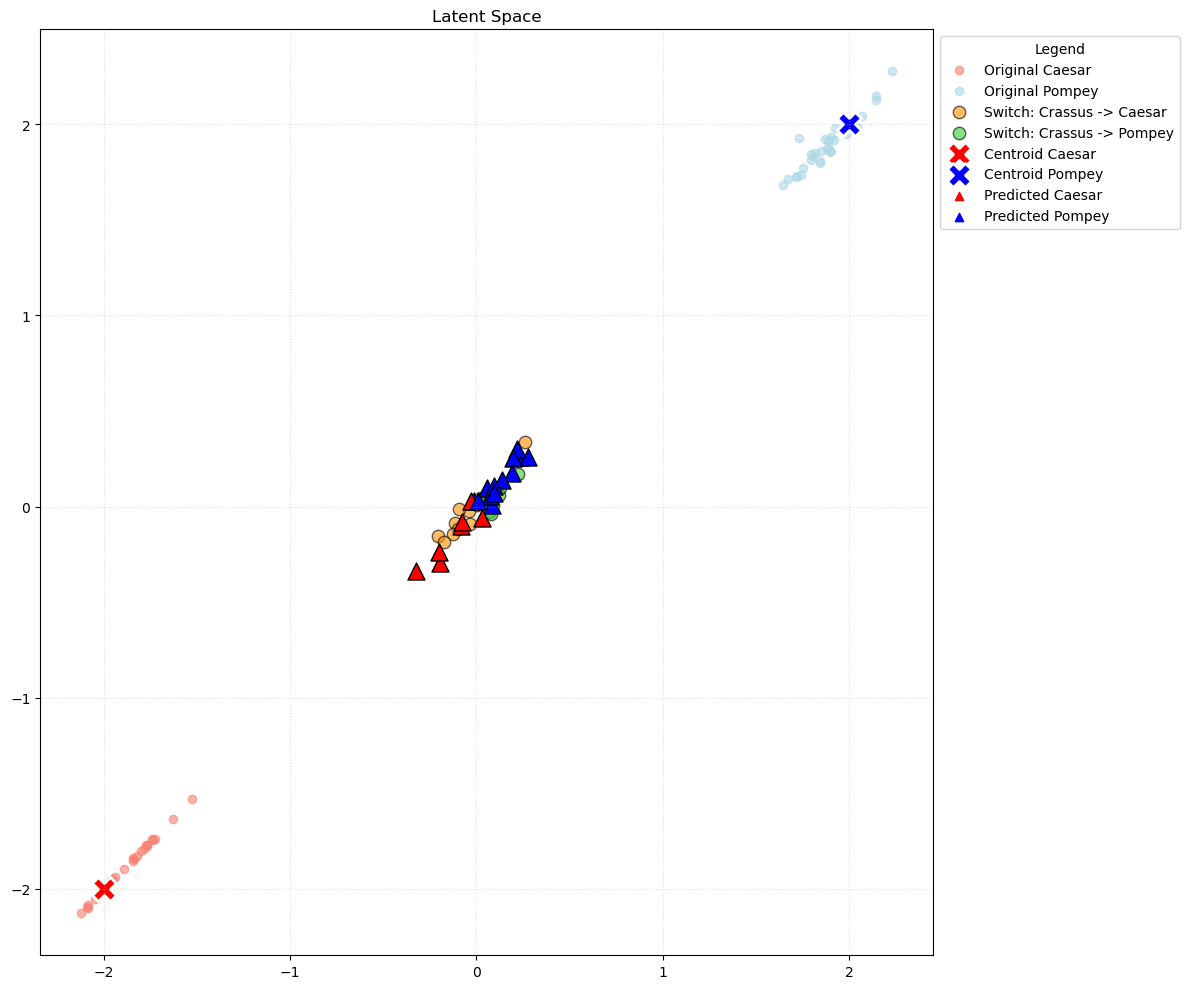

In [48]:
plt.figure(figsize=(12, 10))

#Plot Core Factions (Original Caesar & Pompey)
idx_core_c = [i for i, n in enumerate(nodes) if G.nodes[n]['faction'] in ['Caesar']]
idx_core_p = [i for i, n in enumerate(nodes) if G.nodes[n]['faction'] in ['Pompey']]

plt.scatter(z_post[idx_core_c, 0], z_post[idx_core_c, 1], c='salmon', alpha=0.6, label='Original Caesar')
plt.scatter(z_post[idx_core_p, 0], z_post[idx_core_p, 1], c='lightblue', alpha=0.6, label='Original Pompey')

#Plot Known Switchers from CSV
idx_orange = [] # Crassus -> Caesar
idx_green = []  # Crassus -> Pompey
for _, row in known_assignments_df.iterrows():
    n = row['node_id']
    if G.nodes[n]['faction'] in ['Crassus']:
        idx = node_to_idx[n]
        if row['new_faction'] == 'Caesar': idx_orange.append(idx)
        elif row['new_faction'] == 'Pompey': idx_green.append(idx)

plt.scatter(z_post[idx_orange, 0], z_post[idx_orange, 1], c='darkorange', s=80,alpha=0.6 ,
            edgecolors='black', marker='o', label='Switch: Crassus -> Caesar')
plt.scatter(z_post[idx_green, 0], z_post[idx_green, 1], c='limegreen', s=80, alpha=0.6,
            edgecolors='black', marker='o', label='Switch: Crassus -> Pompey')

#Plot Predictions (Unknowns)
for _, r in df_res.iterrows():
    col = 'red' if r['choice']=='Caesar' else 'blue'
    idx = node_to_idx[r['node']]
    plt.scatter(z_post[idx, 0], z_post[idx, 1], c=col, marker='^', s=150, edgecolors='k')

#Centroids
plt.scatter(C_center[0], C_center[1], c='red', s=300, marker='X', edgecolors='white', linewidth=2, label='Centroid Caesar')
plt.scatter(P_center[0], P_center[1], c='blue', s=300, marker='X', edgecolors='white', linewidth=2, label='Centroid Pompey')

#Dummy legends for predictions
plt.scatter([], [], c='red', marker='^', label='Predicted Caesar')
plt.scatter([], [], c='blue', marker='^', label='Predicted Pompey')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.title(f"Latent Space")
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

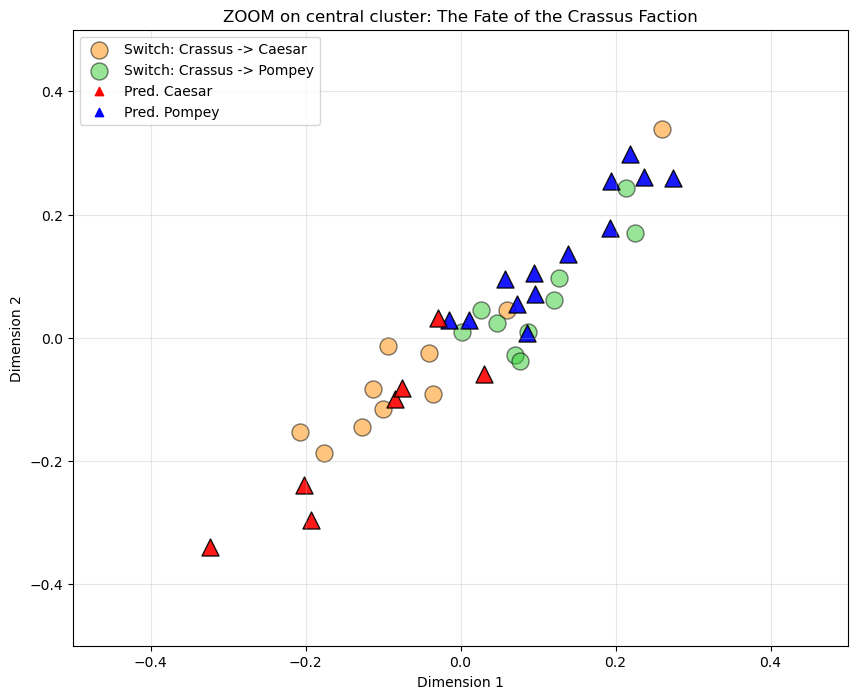

In [69]:
plt.figure(figsize=(10, 8))

plt.scatter(z_post[idx_orange, 0], z_post[idx_orange, 1], c='darkorange', s=150, alpha=0.5,
            edgecolors='black', marker='o', label='Switch: Crassus -> Caesar')
plt.scatter(z_post[idx_green, 0], z_post[idx_green, 1], c='limegreen', s=150, alpha=0.5,
            edgecolors='black', marker='o', label='Switch: Crassus -> Pompey')

for _, r in df_res.iterrows():
    col = 'red' if r['choice']=='Caesar' else 'blue'
    idx = node_to_idx[r['node']]
    plt.scatter(z_post[idx, 0], z_post[idx, 1], c=col, marker='^', s=150, edgecolors='k', alpha=0.9)

plt.scatter([], [], c='red', marker='^', label='Pred. Caesar')
plt.scatter([], [], c='blue', marker='^', label='Pred. Pompey')
plt.legend(loc='upper left')
plt.title("ZOOM on central cluster: The Fate of the Crassus Faction")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.xlim(-0.5, 0.5)
plt.ylim(-0.5, 0.5)
plt.grid(True, alpha=0.3)
plt.show()

## Q2: Who are the most undecided politicians when it comes to choosing between Caesar and Pompey?

An "undecided" politician is one who does not clearly belong to either faction's orbit

Translation to Latent Space

In our geometric model, membership is defined by proximity.

==> We need to find the politicians who are aprox. equidistant from both the Caesar Centroid and the Pompey Centroid

In [62]:
results = []
for n in unknown_nodes:
    idx = node_to_idx[n]
    pos = z_post[idx]
    d_c = np.linalg.norm(pos - C_center)
    d_p = np.linalg.norm(pos - P_center)
    res = {'node': n, 'uncertainty': abs(d_c - d_p)}
    results.append(res)

most_undecided = pd.DataFrame(results).sort_values('uncertainty', ascending=True).head(3)

print("Top 3 Most Undecided Politicians (Closest to Decision Boundary):")
print(most_undecided)

Top 3 Most Undecided Politicians (Closest to Decision Boundary):
    node  uncertainty
11    80     0.002745
10    79     0.019231
16    89     0.041722


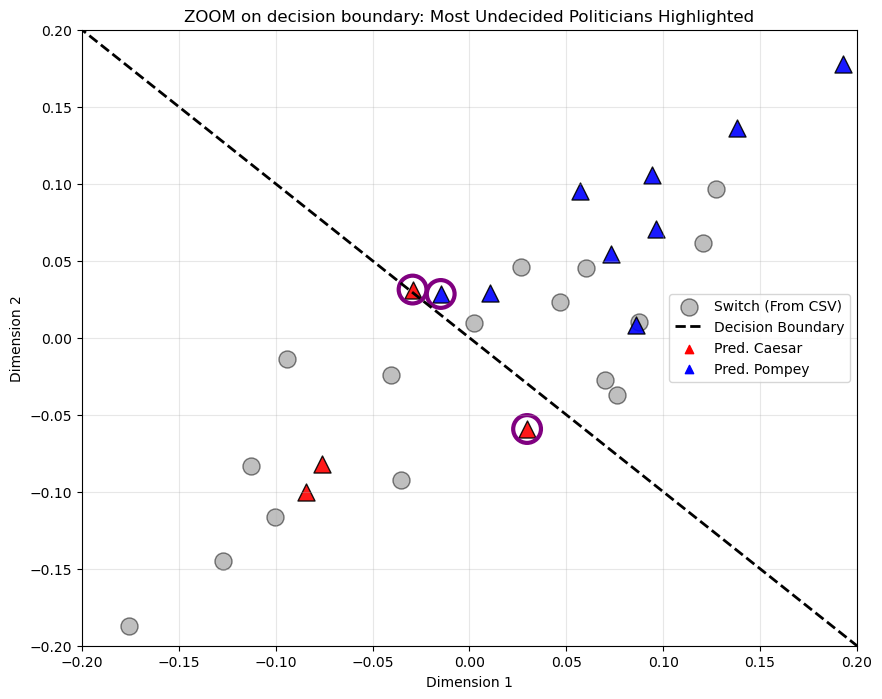

In [68]:
plt.figure(figsize=(10, 8))

plt.scatter(z_post[idx_orange, 0], z_post[idx_orange, 1], c='gray', s=150, alpha=0.5,
            edgecolors='black', marker='o', label='Switch (From CSV)')
plt.scatter(z_post[idx_green, 0], z_post[idx_green, 1], c='gray', s=150, alpha=0.5,
            edgecolors='black', marker='o')

for _, r in df_res.iterrows():
    col = 'red' if r['choice']=='Caesar' else 'blue'
    idx = node_to_idx[r['node']]
    plt.scatter(z_post[idx, 0], z_post[idx, 1], c=col, marker='^', s=150, edgecolors='k', alpha=0.9)

x_vals = np.linspace(-1, 1, 100) 
y_vals = -1 * x_vals             
plt.plot(x_vals, y_vals, 'k--', linewidth=2, label='Decision Boundary')

for _, row in most_undecided.iterrows():
    idx = node_to_idx[row['node']]
    plt.scatter(z_post[idx, 0], z_post[idx, 1], s=400, facecolors='none', edgecolors='purple', linewidth=3)

plt.scatter([], [], c='red', marker='^', label='Pred. Caesar')
plt.scatter([], [], c='blue', marker='^', label='Pred. Pompey')
plt.legend(loc='best')
plt.title("ZOOM on decision boundary: Most Undecided Politicians Highlighted")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.xlim(-0.2, 0.2)
plt.ylim(-0.2, 0.2)
plt.grid(True, alpha=0.3)
plt.show()

## Final Answers

- **Q1** : 
    - **Pompey** gathered the most

- **Q2** :
    - Top 3 undecided politicians: **Nodes : 80, 79, 89**